<a href="https://colab.research.google.com/github/ibrahimhanifceker/YZ50Codes/blob/main/hafta-2/YZ50Hafta2Kod.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [47]:
class Value:
    def __init__(self, data, _children=(), _op='', label = ''):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __add__(self, other):
        out = Value(self.data + other.data, _children=(self, other), _op='+')
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, _children=(self, other), _op='*')
        return out

    def __repr__(self):
        return f"Value: {self.data}"

a = Value(5, label='a')
b = Value(3, label='b')
c = a * b
c.label = 'c'
d = Value(9, label='d')
e = Value(-4, label='e')
f = d * e
f.label='f'
g = c + f
g.label='g'
h = Value(-7, label='h')
L = g * h
L.label='L'

{Value: -36, Value: -4, Value: -7, Value: 15, Value: 147, Value: 9, Value: 5, Value: 3, Value: -21}


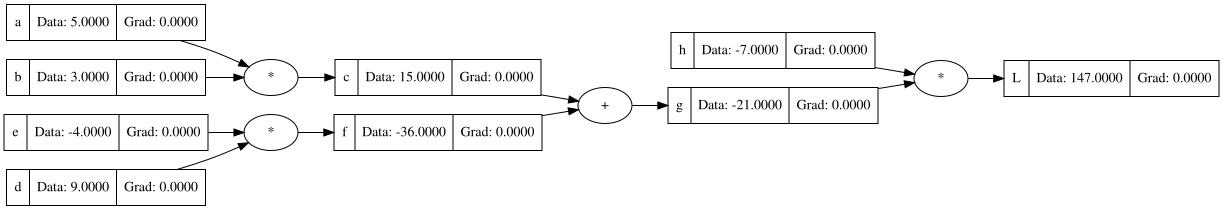

In [48]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v in nodes:
            return
        nodes.add(v)
        for child in v._prev:
            edges.add((v, child))
            build(child)

    build(root)

    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})

    nodes, edges = trace(root)
    print(nodes)
    for node in nodes:
        dot.node(name=str(id(node)), label="{%s | Data: %.4f | Grad: %.4f}" % (node.label, node.data, node.grad), shape='record')

        if node._op != '':
            dot.node(name=str(id(node))+'op', label=node._op)
            dot.edge(str(id(node))+'op', str(id(node)))

    for edge in edges:
        dot.edge(str(id(edge[1])), str(id(edge[0]))+'op')

    return dot

draw_dot(L)